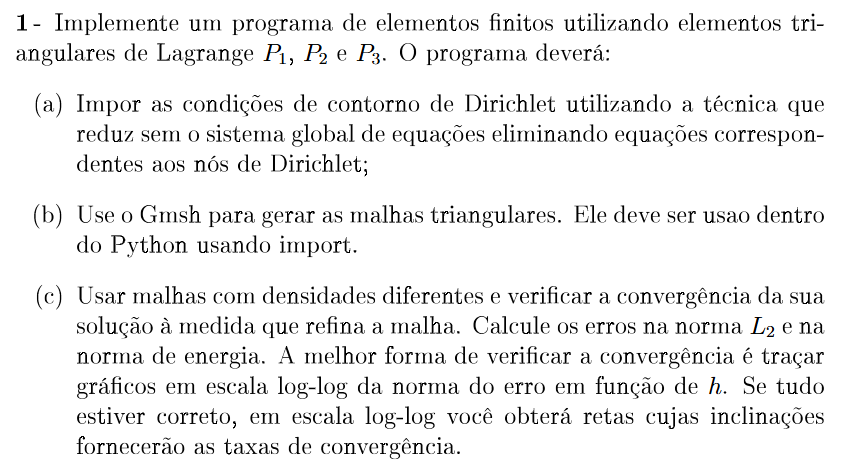

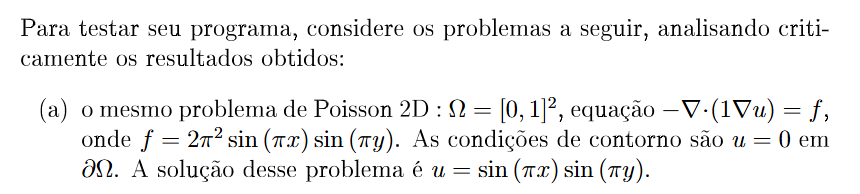

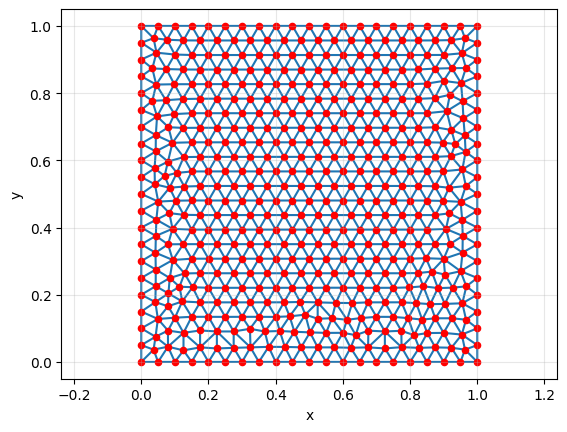

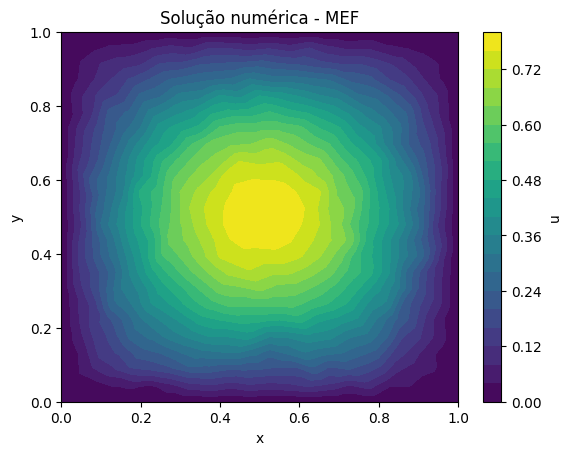

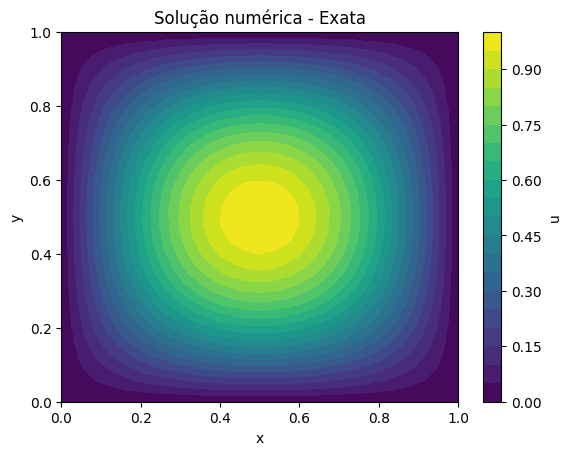

TypeError: shape_functions() missing 1 required positional argument: 'order'

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import spsolve

from engine import assemble_system
from boundary_conditions import apply_dirichlet
from mesh import sqr_mesh2D

p = 1

malha = sqr_mesh2D(lc=0.05,lim_inf=0.0,lim_sup=1.0,show_mesh=True)

f = lambda x, y: 2 * np.pi**2 * np.sin(np.pi*x) * np.sin(np.pi*y)

K, F = assemble_system(malha.nodes,malha.triangles,p,f)

dirichlet_dofs = np.unique(malha.boundary_faces)
dirichlet_values = np.zeros(len(dirichlet_dofs))

Kff, Ff, free_dofs = apply_dirichlet(K, F, dirichlet_dofs, dirichlet_values)

#u_free = spsolve(Kff, Ff)
u_free = spsolve(csr_matrix(Kff),Ff)

u = np.zeros(len(F))

u[dirichlet_dofs] = dirichlet_values
u[free_dofs] = u_free

x = malha.nodes[:,0]
y = malha.nodes[:,1]

u_exact = (np.sin(np.pi * x)* np.sin(np.pi * y))

#--------------------------------------------------#

triang = mtri.Triangulation(x, y, malha.triangles)

plt.figure()
plt.tricontourf(triang,u,levels=20)
plt.colorbar(label="u")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Solução numérica - MEF")
plt.show()

plt.figure()
plt.tricontourf(triang,u_exact,levels=20)
plt.colorbar(label="u")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Solução numérica - Exata")
plt.show()


error_l2 = l2_error(malha,u,p)

print("Norma L2 do erro =", error_l2)